# Difusao: Langevin + denoising score matching

Modelos de difusao geram amostras seguindo uma equacao diferencial estocastica cuja
distribuicao estacionaria e a densidade dos dados. Para isso precisamos do *score*,
o campo `grad log p(x)`, que aprendemos de forma supervisionada com denoising score
matching (DSM).

O roteiro e:

1. Euler-Maruyama para ilustrar o que e um processo de Ito.
2. Definir a dinamica de Langevin.
3. Aprender o score via DSM (regressao supervisionada, usando uma floresta).
4. Treinar com varios niveis de ruido e gerar amostras com Langevin anelado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_moons, make_circles

rng = np.random.default_rng(0)

## 1. Processo de Ito e Euler-Maruyama

Um processo de Ito segue uma equacao diferencial estocastica (EDS):

$$dX = f(X)\,dt + g(X)\,dW$$

O termo $f$ e o arrasto (*drift*, deterministico) e $g\,dW$ e a difusao, com $dW$ um
incremento de ruido branco. O metodo de Euler-Maruyama discretiza a EDS:

$$X_{t+\Delta t} = X_t + f(X_t)\,\Delta t + g(X_t)\,\sqrt{\Delta t}\,z,
\qquad z \sim \mathcal{N}(0, 1)$$

Escrevemos a simulacao em funcao de uma funcao de drift $f$. Como exemplo usamos o
processo de Ornstein-Uhlenbeck, $f(X) = -\theta X$, que sempre volta para zero.

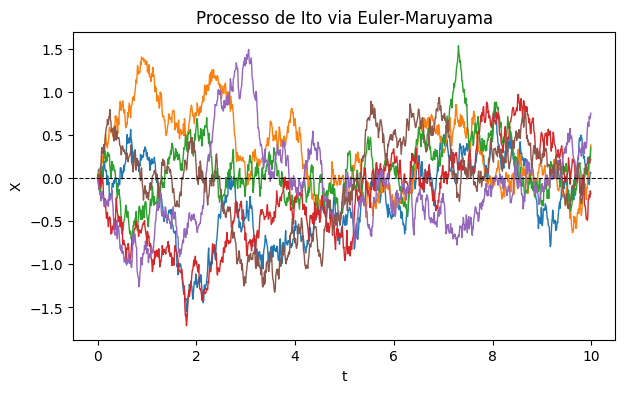

In [2]:
sigma = 0.7        # intensidade da difusao g
theta = 1.0

# funcao de drift f(X): escolha uma (as outras ficam comentadas)
def drift(x):
    return -theta * x                  # Ornstein-Uhlenbeck (volta para 0)
    # return -theta * (x - 3.0)        # volta para a media 3.0
    # return x - x ** 3                # poco duplo (dois pontos estaveis)
    # return np.zeros_like(x)          # difusao pura (passeio aleatorio)

dt = 0.01
passos = 1000
n_traj = 6

X = np.zeros((n_traj, passos))
for t in range(passos - 1):
    z = rng.standard_normal(n_traj)
    X[:, t + 1] = X[:, t] + drift(X[:, t]) * dt + sigma * np.sqrt(dt) * z

tempo = np.arange(passos) * dt
plt.figure(figsize=(7, 4))
for i in range(n_traj):
    plt.plot(tempo, X[i], lw=1)
plt.axhline(0, color='k', lw=0.8, ls='--')
plt.title('Processo de Ito via Euler-Maruyama')
plt.xlabel('t')
plt.ylabel('X')
plt.show()

## 2. Dinamica de Langevin

A dinamica de Langevin e um processo de Ito particular cuja distribuicao estacionaria
e uma densidade alvo $p$:

$$dX = \tfrac{1}{2}\,\nabla \log p(X)\,dt + dW$$

O campo $\nabla \log p(x)$ e o *score*. Se soubermos o score, rodar Langevin faz os
pontos se acumularem onde $p$ e grande. Discretizando com passo $\epsilon$:

$$X_{t+1} = X_t + \tfrac{\epsilon}{2}\,\mathrm{score}(X_t) + \sqrt{\epsilon}\,z$$

Para ilustrar, usamos uma mistura de gaussianas na reta (1D), onde tanto a densidade
quanto o score tem forma fechada (aqui $\sigma$ e o `escala` do codigo):

$$p(x) = \sum_k w_k\,\mathcal{N}(x; \mu_k, \sigma^2)$$

$$\mathrm{score}(x) = \frac{1}{p(x)} \sum_k w_k\,\mathcal{N}_k(x)\,\frac{\mu_k - x}{\sigma^2}$$

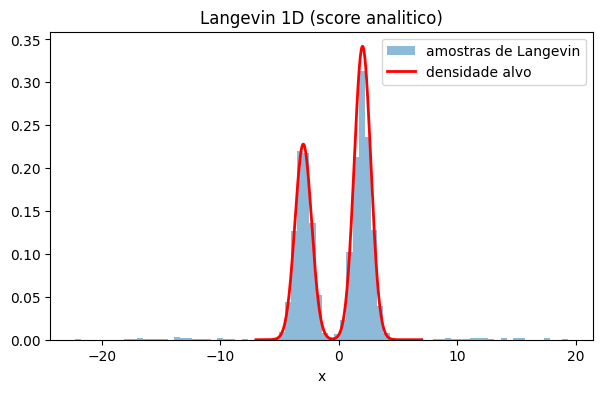

In [3]:
mus = np.array([-3.0, 2.0])
pesos = np.array([0.4, 0.6])
escala = 0.7

def densidade(x):
    comp = pesos[None, :] * np.exp(-(x[:, None] - mus[None, :]) ** 2 / (2 * escala ** 2))
    comp = comp / (np.sqrt(2 * np.pi) * escala)
    return comp.sum(1)

def score_gmm(x):
    comp = pesos[None, :] * np.exp(-(x[:, None] - mus[None, :]) ** 2 / (2 * escala ** 2))
    p = comp.sum(1)
    num = (comp * (mus[None, :] - x[:, None]) / escala ** 2).sum(1)
    return num / (p + 1e-12)

eps = 0.05
passos = 400
n = 4000

x = rng.standard_normal(n) * 4
for _ in range(passos):
    z = rng.standard_normal(n)
    x = x + 0.5 * eps * score_gmm(x) + np.sqrt(eps) * z

grade = np.linspace(-7, 7, 400)
plt.figure(figsize=(7, 4))
plt.hist(x, bins=80, density=True, alpha=0.5, label='amostras de Langevin')
plt.plot(grade, densidade(grade), 'r', lw=2, label='densidade alvo')
plt.legend()
plt.title('Langevin 1D (score analitico)')
plt.xlabel('x')
plt.show()

## 3. Aprendendo o score via DSM

Na pratica nao conhecemos `p` nem o score. O denoising score matching resolve isso
como uma regressao supervisionada.

Perturbamos cada ponto $x$ com ruido gaussiano:

$$\tilde{x} = x + \sigma\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

O score do nucleo de perturbacao tem alvo conhecido:

$$\nabla_{\tilde{x}} \log q(\tilde{x} \mid x) = \frac{x - \tilde{x}}{\sigma^2} = -\frac{\varepsilon}{\sigma}$$

Entao basta uma regressao: entrada $\tilde{x}$, alvo $(x - \tilde{x})/\sigma^2$.
Qualquer regressor serve; aqui usamos uma floresta aleatoria.

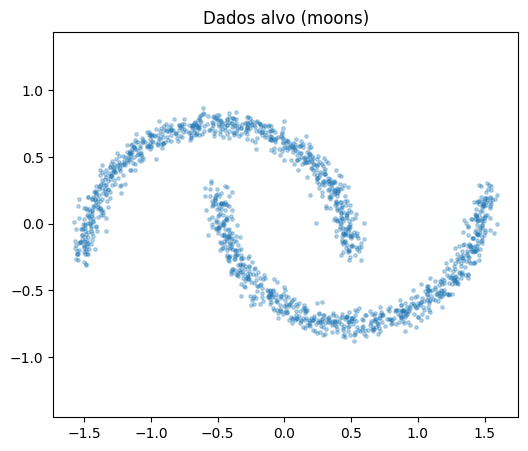

In [4]:
dataset = 'moons'          # 'moons' ou 'circles'

if dataset == 'moons':
    X_dados, _ = make_moons(n_samples=1500, noise=0.05, random_state=0)
else:
    X_dados, _ = make_circles(n_samples=1500, noise=0.05, factor=0.5, random_state=0)
X_dados = X_dados - X_dados.mean(0)

plt.figure(figsize=(6, 5))
plt.scatter(X_dados[:, 0], X_dados[:, 1], s=6, alpha=0.3)
plt.title(f'Dados alvo ({dataset})')
plt.axis('equal')
plt.show()

In [5]:
sigma = 0.15
eps_ruido = rng.standard_normal(X_dados.shape)
X_ruido = X_dados + sigma * eps_ruido
alvo_score = (X_dados - X_ruido) / sigma ** 2          # = -eps_ruido / sigma

modelo = RandomForestRegressor(
    n_estimators=100, min_samples_leaf=10, n_jobs=-1, random_state=0
)
modelo.fit(X_ruido, alvo_score)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

Com o score aprendido, rodamos Langevin. O passo $\epsilon = \sigma^2$ mantem a escala
do ruido coerente com a usada no treino.

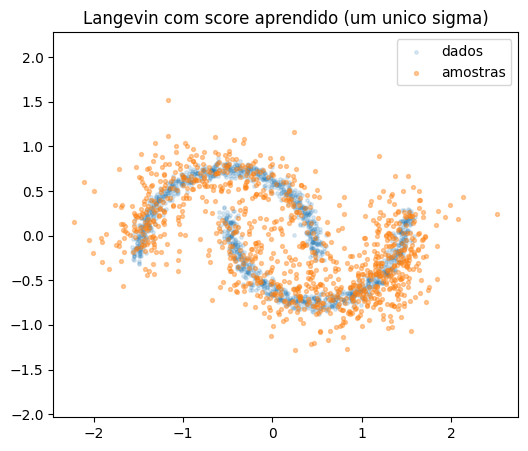

In [6]:
eps = sigma ** 2
passos = 150
n = 1000

x = rng.standard_normal((n, 2))
for _ in range(passos):
    z = rng.standard_normal((n, 2))
    s = modelo.predict(x)
    x = x + 0.5 * eps * s + np.sqrt(eps) * z

plt.figure(figsize=(6, 5))
plt.scatter(X_dados[:, 0], X_dados[:, 1], s=6, alpha=0.15, label='dados')
plt.scatter(x[:, 0], x[:, 1], s=8, alpha=0.4, label='amostras')
plt.legend()
plt.title('Langevin com score aprendido (um unico sigma)')
plt.axis('equal')
plt.show()

Com um unico $\sigma$ temos um dilema: $\sigma$ grande borra os dados e $\sigma$ pequeno
nao da informacao em regioes vazias, longe da nuvem de dados. A amostragem fica ruim
justamente onde o ponto inicial costuma cair. A solucao e usar varios niveis de ruido.

## 4. Langevin anelado (varios niveis de ruido)

A ideia (Song & Ermon, 2019) e treinar **um** regressor condicionado no nivel de ruido:
entrada $[\tilde{x}, \sigma]$, alvo $(x - \tilde{x})/\sigma^2$. Assim o modelo aprende o
score em todas as escalas de uma vez.

Na amostragem, comecamos do ruido grande e diminuimos $\sigma$ aos poucos (anelamento),
com passo proporcional a $\sigma^2$. O ruido grande guia os pontos de longe ate a nuvem
de dados; o ruido pequeno refina os detalhes.

In [7]:
sigmas = np.geomspace(1.0, 0.05, 8)

entradas = []
alvos = []
for s in sigmas:
    eps_ruido = rng.standard_normal(X_dados.shape)
    X_ruido = X_dados + s * eps_ruido
    coluna_s = np.full((X_dados.shape[0], 1), s)
    entradas.append(np.hstack([X_ruido, coluna_s]))
    alvos.append((X_dados - X_ruido) / s ** 2)

entradas = np.vstack(entradas)
alvos = np.vstack(alvos)
print('banco de treino:', entradas.shape)

modelo_cond = RandomForestRegressor(
    n_estimators=100, min_samples_leaf=10, n_jobs=-1, random_state=0
)
modelo_cond.fit(entradas, alvos)

def score_cond(x, s):
    entrada = np.hstack([x, np.full((x.shape[0], 1), s)])
    return modelo_cond.predict(entrada)

banco de treino: (12000, 3)


### Conferindo o campo de score

Antes de amostrar, vale ver o campo aprendido. As setas abaixo sao o score
$\,\mathrm{score}(x, \sigma)$ **normalizado** em cada ponto de uma grade, para um
$\sigma$ fixo. Como o score aponta na direcao em que $\log p$ cresce, as setas devem
apontar para a nuvem de dados — exatamente a direcao que Langevin usa para empurrar os
pontos para a regiao de alta densidade.

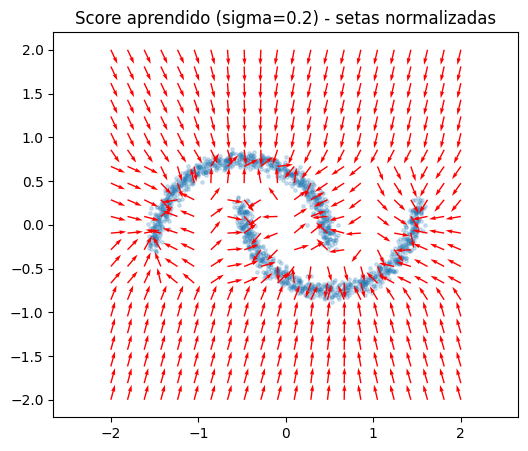

In [8]:
s_vis = 0.2
lim = 2.0
gx, gy = np.meshgrid(np.linspace(-lim, lim, 22), np.linspace(-lim, lim, 22))
grade_xy = np.column_stack([gx.ravel(), gy.ravel()])

vec = score_cond(grade_xy, s_vis)
vec = vec / (np.linalg.norm(vec, axis=1, keepdims=True) + 1e-8)   # normaliza

plt.figure(figsize=(6, 5))
plt.scatter(X_dados[:, 0], X_dados[:, 1], s=6, alpha=0.2, label='dados')
plt.quiver(gx, gy, vec[:, 0].reshape(gx.shape), vec[:, 1].reshape(gx.shape),
           color='red', angles='xy', scale=30, width=0.003)
plt.title(f'Score aprendido (sigma={s_vis}) - setas normalizadas')
plt.axis('equal')
plt.show()

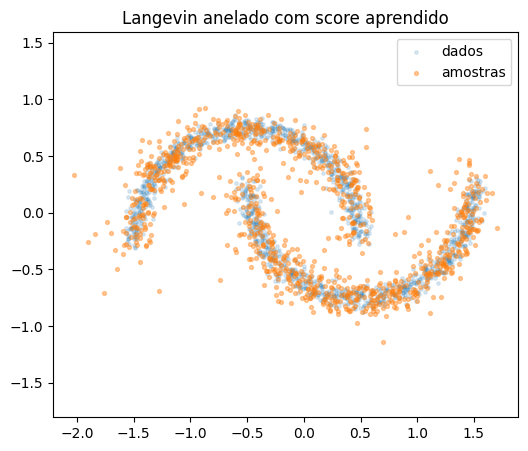

In [9]:
n = 1000
T = 40            # passos de Langevin por nivel
c = 0.2           # fator do passo (alpha = c * sigma^2)

x = rng.standard_normal((n, 2)) * sigmas[0]
for s in sigmas:
    alpha = c * s ** 2
    for _ in range(T):
        z = rng.standard_normal((n, 2))
        x = x + 0.5 * alpha * score_cond(x, s) + np.sqrt(alpha) * z

plt.figure(figsize=(6, 5))
plt.scatter(X_dados[:, 0], X_dados[:, 1], s=6, alpha=0.15, label='dados')
plt.scatter(x[:, 0], x[:, 1], s=8, alpha=0.4, label='amostras')
plt.legend()
plt.title('Langevin anelado com score aprendido')
plt.axis('equal')
plt.show()

Agora as amostras cobrem bem a forma dos dados. Cada nivel de ruido empurra os pontos
perto da nuvem de dados, e os ultimos niveis (sigma pequeno) ajustam os detalhes.
Esse e o mesmo principio por tras de modelos de difusao modernos, trocando a floresta
por uma rede neural e o anelamento por um cronograma continuo de ruido.